**Master en Bioinformática y Biología Computacional, UAM**
## **Minería de texto**
# **Práctica de laboratorio 3: Redes neuronales para análisis de sentimientos**


---



# ***Ejercicio 1 - FFNs***

# Carga y preprocesado de datos - One-hot encoding

In [1]:
# Montamos el drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install tensorflow

# Fijamos semillas para generación de números aleatorios
import numpy as np
import tensorflow as tf

np.random.seed(1)
tf.random.set_seed(2)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [3]:
import re
import pandas as pd

# Utilizamos el Stanford Sentiment Treebank (SST) como corpus de prueba para análisis de sentimientos de textos
# Cargamos y procesamos los datos para tratarlos como un problema de clasificación binaria de sentimientos
# Convertimos la escala de sentimientos de [1,5] a {0,1}
def load_sst_dataset(file_path, label_map={0:0, 1:0, 2:None, 3:1, 4:1}):
    data = []
    with open(file_path) as f:
        for i, line in enumerate(f):
            instance = {}
            instance['label'] = label_map[int(line[1])]
            if instance['label'] is None:
                continue

            # Filtramos caracteres y etiquetas de parseo
            text = re.sub(r'\s*(\(\d)|(\))\s*', '', line)
            instance['text'] = text[1:]
            data.append(instance)
    data = pd.DataFrame(data)
    return data

data_folder = 'drive/My Drive/Colab Notebooks/mintex2526-lab3/data/'
training_set = load_sst_dataset(data_folder + 'sst_training.txt') # conjunto de datos de entrenamiento
validation_set = load_sst_dataset(data_folder + 'sst_validation.txt') # conjunto de datos de validación
test_set = load_sst_dataset(data_folder + 'sst_test.txt') # conjunto de datos de test

print('Instancias de entrenamiento: {}'.format(len(training_set)))
print('Instancias de de validación: {}'.format(len(validation_set)))
print('Instancias de de test: {}'.format(len(test_set)))

Instancias de entrenamiento: 6920
Instancias de de validación: 872
Instancias de de test: 1821


In [4]:
from tensorflow.keras.preprocessing import text
from sklearn.utils import shuffle

# Desordenamos los conjuntos de datos
training_set = shuffle(training_set)
validation_set = shuffle(validation_set)
test_set = shuffle(test_set)

# Separamos textos y etiquetas de los conjuntos de datos
training_texts = training_set.text
training_labels = training_set.label
validation_texts = validation_set.text
validation_labels = validation_set.label
test_texts = test_set.text
test_labels = test_set.label

# Construimos un índice (vocabulario) para las 1000 palabras más frecuentes en el conjunto de datos de entrenamiento
tokenizer = text.Tokenizer(num_words=1000)
tokenizer.fit_on_texts(training_texts)

print("10 palabras del vocabulario con mayor frecuencia:")
words_index = tokenizer.word_index
for word, index in list(words_index.items())[:10]:
    count = tokenizer.word_counts[word]
    print(f"\t{word}  (índice: {index}, frecuencia: {count})")
print()

print("10 palabras del vocabulario con menor frecuencia:")
sorted_word_counts = sorted(tokenizer.word_counts.items(), key=lambda x: x[1], reverse=False)
last_words_counts = sorted_word_counts[:10]
for word, count in last_words_counts:
    index = tokenizer.word_index[word]
    print(f"\t{word}  (índice: {index}, frecuencia: {count})")

10 palabras del vocabulario con mayor frecuencia:
	the  (índice: 1, frecuencia: 5996)
	a  (índice: 2, frecuencia: 4385)
	and  (índice: 3, frecuencia: 3869)
	of  (índice: 4, frecuencia: 3680)
	to  (índice: 5, frecuencia: 2464)
	is  (índice: 6, frecuencia: 2099)
	's  (índice: 7, frecuencia: 2025)
	it  (índice: 8, frecuencia: 1952)
	that  (índice: 9, frecuencia: 1613)
	in  (índice: 10, frecuencia: 1581)

10 palabras del vocabulario con menor frecuencia:
	aid  (índice: 7198, frecuencia: 1)
	milking  (índice: 7199, frecuencia: 1)
	ken  (índice: 7200, frecuencia: 1)
	vacuous  (índice: 7201, frecuencia: 1)
	embody  (índice: 7202, frecuencia: 1)
	nouvelle  (índice: 7203, frecuencia: 1)
	enact  (índice: 7204, frecuencia: 1)
	chapter  (índice: 7205, frecuencia: 1)
	playwright  (índice: 7206, frecuencia: 1)
	drinker  (índice: 7207, frecuencia: 1)


In [5]:
# Vectorizamos los textos mediante la representación one-hot encoding
x_training = tokenizer.texts_to_matrix(training_texts, mode='binary')
y_training = training_labels
x_validation = tokenizer.texts_to_matrix(validation_texts, mode='binary')
y_validation = validation_labels
x_test = tokenizer.texts_to_matrix(test_texts, mode='binary')
y_test = test_labels

print('Dimensiones del conjunto de entrenamiento: {}'.format(x_training.shape))
print('Dimensiones del conjunto de validación: {}'.format(x_validation.shape))
print('Dimensiones del conjunto de test: {}'.format(x_test.shape))

Dimensiones del conjunto de entrenamiento: (6920, 1000)
Dimensiones del conjunto de validación: (872, 1000)
Dimensiones del conjunto de test: (1821, 1000)


In [6]:
# Comprobación de algunos vectores generados:
# Iteramos sobre n textos (de entrenamiento) y sus vectores correspondientes
n = 3

index_to_word = tokenizer.index_word # Mapeos de índices a palabras en el vocabulario
word_counts = tokenizer.word_counts # Frecuencias de las palabras en los textos

for i, (text, text_vector) in enumerate(zip(training_texts[:n], x_training[:n]), start=1):
    print(f"Texto {i}: {text}")
    print(f"Vector: {text_vector}")
    print("Palabras:")
    for index, value in enumerate(text_vector):
        # Si el valor en el vector es 1, obtenemos la palabra correspondiente, junto con su índice y frecuencia en el vocabulario
        if value == 1:
            word = index_to_word.get(index)
            word_frequency = word_counts.get(word, 0) if word else 0
            print(f"\t{word} (índice={index}, frecuencia={word_frequency})")
    print()

Texto 1: It is dark , brooding and slow , and takes its central idea way too seriously .
Vector: [0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0.

# Construcción de la red

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

input_size = x_training[0].shape[0] # la longitud del vector de entrada es igual al tamaño del vocabulario

# Definimos una red neuronal feedforward con una única capa oculta de 16 unidades
# y ReLU como función de activación
model = Sequential()
model.add(Dense(units=16, activation='relu', input_shape=(input_size,))) # Nota: no es necesario indicar input_shape en capas sucesivas
model.add(Dense(units=1, activation='sigmoid'))

# Compilamos la red usando la entropía cruzada binaria como función de pérdida,
# el algoritmo Adam como optimizador del descenso por gradiente,
# y accuracy como métrica de evaluación en entrenamiento y validación
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Opcionalmente se pueden utilizar otras funciones de activación (e.g., tanh, sigmoid) en vez de ReLU
# y otras funciones de pérdida como mean squared error (MSE)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        16,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,033 (62.63 KB)

 Trainable params: 16,033 (62.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Entrenamos la red durante 100 épocas y con batches de tamaño 32
history = model.fit(x_training, y_training, epochs=100, batch_size=32, validation_data=(x_validation, y_validation), verbose=1)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5674 - loss: 0.6762 - val_accuracy: 0.7431 - val_loss: 0.5696
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7522 - loss: 0.5507 - val_accuracy: 0.7626 - val_loss: 0.5015
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7904 - loss: 0.4731 - val_accuracy: 0.7695 - val_loss: 0.4902
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8067 - loss: 0.4379 - val_accuracy: 0.7672 - val_loss: 0.4939
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8130 - loss: 0.4178 - val_accuracy: 0.7615 - val_loss: 0.5020
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8158 - loss: 0.4039 - val_accuracy: 0.7638 - val_loss: 0.5112
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8170 - loss: 0.3933 - val_accuracy: 0.7603 - val_loss: 0.5204
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8218 - loss: 0.3841 - val_accu

**Ejercicio 1a - Red de una capa oculta**

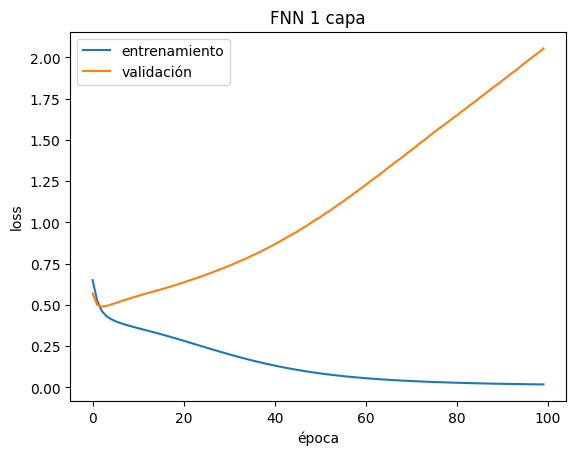

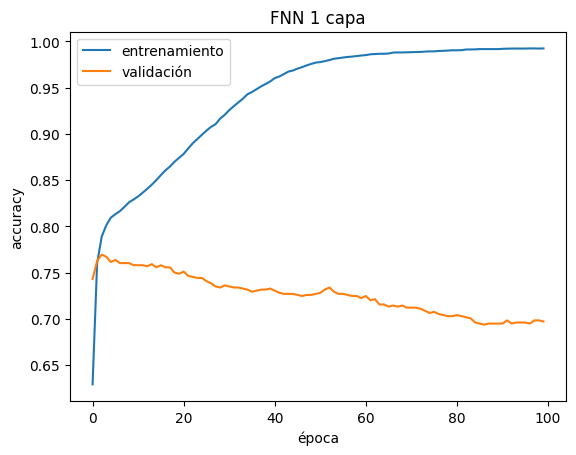

In [9]:
import matplotlib.pyplot as plt

# Visualizamos un gráfica con el LOSS alcanzado en cada época para los conjuntos de entrenamiento y de validación
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('FNN 1 capa')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Visualizamos un gráfica con el ACCURACY alcanzado en cada época para los conjuntos de entrenamiento y de validación
# TO DO
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('FNN 1 capa')
plt.ylabel('accuracy')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

**Ejercicio 1b - Red multicapa**

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │        16,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,305 (63.69 KB)

 Trainable params: 16,305 (63.69 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5650 - loss: 0.6765 - val_accuracy: 0.7397 - val_loss: 0.5447
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7592 - loss: 0.5149 - val_accuracy: 0.7638 - val_loss: 0.4980
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8047 - loss: 0.4316 - val_accuracy: 0.7626 - val_loss: 0.5048
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8284 - loss: 0.3873 - val_accuracy: 0.7626 - val_loss: 0.5197
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8452 - loss: 0.3504 - val_accuracy: 0.7557 - val_loss: 0.5412
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8652 - loss: 0.3145 - val_accuracy: 0.7546 - val_loss: 0.5715
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8819 - loss: 0.2792 - val_accuracy: 0.7466 - val_loss: 0.6024
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9026 - loss: 0.2448 - val_accu

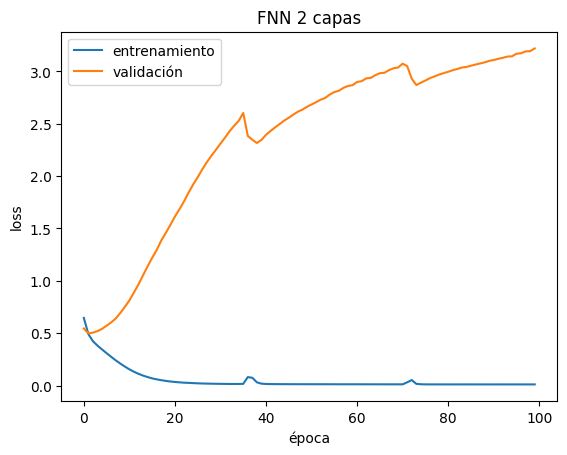

In [10]:
# Añadimos una capa oculta adicional al modelo
model = Sequential()
# TO DO
model.add(Dense(units=16, activation='relu', input_shape=(input_size,)))
model.add(Dense(units=16, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))


model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

history_2 = model.fit(x_training, y_training, epochs=100, batch_size=32, validation_data=(x_validation, y_validation), verbose=1)

# Visualizamos una gráfica con la evolución de LOSS alcanzado en cada época para los conjuntos de entrenamiento y de validación
# TO DO
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('FNN 2 capas')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

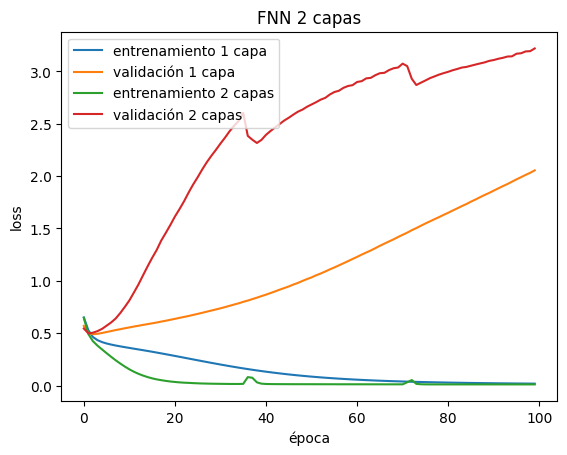

In [11]:
# Visualizamos una gráfica comparativa de la evolución de LOSS por épocas usando una o dos capas ocultas
plt.title('FNN 1 capa vs. 2 capas')
# TO DO
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('FNN 2 capas')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento 1 capa', 'validación 1 capa','entrenamiento 2 capas',
            'validación 2 capas'], loc='upper left')
plt.show()


**Ejercicio 1c - Evaluación de hiperparámetros mediante grid search**

In [12]:
# Comentario: para generar un modelo configurado con una serie de parámetros dada se aconseja implementar una función get_model,
# que recibe tales parámetros como argumentos de entrada, y retorna el modelo correspondiente como salida
def get_model(lrs, regs, drs):
    model = Sequential()

    # Capa oculta 1: 512 unidades
    model.add(Dense(units=512, activation='relu', input_shape=(input_size,), kernel_regularizer=l2(regs)))
    model.add(Dropout(drs))

    # Capa oculta 2: 256 unidades
    model.add(Dense(units=256, activation='relu', kernel_regularizer=l2(regs)))
    model.add(Dropout(drs))

    # Capa oculta 3: 128 unidades
    model.add(Dense(units=128, activation='relu', kernel_regularizer=l2(regs)))

    # Capa de salida
    model.add(Dense(1, activation='sigmoid'))

    optimizer = Adam(learning_rate=lrs)

    model.compile(
        loss='binary_crossentropy',
        optimizer=optimizer,
        metrics=['accuracy']
    )

    return model

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import time
lrs = [0.0001, 0.001, 0.01] # valores de la learning rate
regs = [0.0, 0.0001] # valores de regularización L2
drs = [0.0, 0.2, 0.5] # valores de dropout

num_epochs = 100
early_stop = EarlyStopping(monitor='val_loss', patience=1) # para parar el entrenamiento antes de num_epochs atendiendo al error en validación

# Imprimimos por pantalla los valores valores de LOSS y ACCURACY de entrenamiento y validación de cada modelo, época a epóca
histories = {}
for lr in lrs:
    for reg in regs:
        for dr in drs:
            # TO DO
            print(f"lr={lr}, reg={reg}, dr={dr}")
            model = get_model(lr, reg, dr)
            history = model.fit(x_training, y_training, epochs=100,batch_size=32,
                                validation_data=(x_validation, y_validation), verbose=1,
                                callbacks=[early_stop])
            histories[(lr, reg, dr)] = history

lr=0.0001, reg=0.0, dr=0.0
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5499 - loss: 0.6849 - val_accuracy: 0.6938 - val_loss: 0.6336
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7155 - loss: 0.5938 - val_accuracy: 0.7466 - val_loss: 0.5196
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8018 - loss: 0.4446 - val_accuracy: 0.7638 - val_loss: 0.5053
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8550 - loss: 0.3475 - val_accuracy: 0.7626 - val_loss: 0.5304
lr=0.0001, reg=0.0, dr=0.2
Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5283 - loss: 0.6910 - val_accuracy: 0.6846 - val_loss: 0.6576
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6711 - loss: 0.6392 - val_accuracy: 0.7523 - val_loss: 0.5362
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7648 - loss: 0.5139 - val_accuracy: 0.7798 - val_loss: 0.4880
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s

In [13]:
# Obtenemos y visualizamos los parámetros de la mejor época atendiendo a los valores de ACCURACY en validación
# TO DO
best_params = None
best_accuracy = 0.0
for params, history in histories.items():
    val_accuracy = history.history['val_accuracy'][-1]
    if val_accuracy > best_accuracy:
        best_accuracy = val_accuracy
        best_params = params
        best_history = history

print("Mejores parámetros: lr={}, reg={}, dr={}".format(*best_params))
print("Mejor accuracy en validación: {}".format(best_accuracy))


Mejores parámetros: lr=0.0001, reg=0.0001, dr=0.5
Mejor accuracy en validación: 0.7763761281967163


In [15]:
import pandas as pd
import numpy as np

results = []

for params, history in histories.items():
    lr, reg, dr = params

    # Buscamos el mejor valor de accuracy en validación/test
    val_acc_values = history.history['val_accuracy']
    best_val_acc = max(val_acc_values)

    # Buscamos la época donde se alcanzó ese valor óptimo
    best_epoch_index = np.argmax(val_acc_values)
    best_epoch = best_epoch_index + 1 # Época empieza en 1, no en 0

    # Almacenamos los resultados
    results.append({
        'LR': lr,
        'Reg L2': reg,
        'Dropout': dr,
        'Mejor Accuracy Test': f"{best_val_acc:.4f}",
        'Época óptima': best_epoch
    })

# Convertimos la lista de diccionarios a un DataFrame de Pandas
results_df = pd.DataFrame(results)

# Ordenamos por mejor accuracy en test
results_df = results_df.sort_values(by='Mejor Accuracy Test', ascending=False)

# Install tabulate for to_markdown() if not already installed
!pip install tabulate

print("\n" + "=" * 60)
print("             TABLA DE EVALUACIÓN DE GRID SEARCH")
print("=" * 60)
print(results_df.to_markdown(index=False))


             TABLA DE EVALUACIÓN DE GRID SEARCH
|     LR |   Reg L2 |   Dropout |   Mejor Accuracy Test |   Época óptima |
|-------:|---------:|----------:|----------------------:|---------------:|
| 0.0001 |   0      |       0.2 |                0.7798 |              3 |
| 0.0001 |   0.0001 |       0.5 |                0.7764 |              7 |
| 0.0001 |   0      |       0.5 |                0.7752 |              5 |
| 0.0001 |   0.0001 |       0   |                0.7718 |              3 |
| 0.001  |   0      |       0.2 |                0.7683 |              1 |
| 0.001  |   0.0001 |       0.5 |                0.7649 |              2 |
| 0.0001 |   0      |       0   |                0.7638 |              3 |
| 0.0001 |   0.0001 |       0.2 |                0.7626 |              4 |
| 0.01   |   0      |       0.5 |                0.7615 |              1 |
| 0.001  |   0.0001 |       0   |                0.7603 |              1 |
| 0.001  |   0      |       0   |                0.

# ***Ejercicio 2 - LSTMs***

# Preprocesado de datos - Tokenization y sequence padding

In [16]:
from tensorflow.keras import preprocessing

# Creamos un tokenier que considera las 10000 palabras más frecuentes en el corpus
max_words = 10000
tokenizer = preprocessing.text.Tokenizer(num_words=max_words)

# Construimos el índice (diccionario) de palabras a partir del conjunto de datos de entrenamiento
tokenizer.fit_on_texts(training_texts)
word_index = tokenizer.word_index

# Obtenemos los textos como secuencias de enteros
trainining_sequences = tokenizer.texts_to_sequences(training_texts)
validation_sequences = tokenizer.texts_to_sequences(validation_texts)
test_sequences = tokenizer.texts_to_sequences(test_texts)

# Padding: convertimos las secuencias de enteros a un tensor 2D de forma (numero_secuencias, longitud_secuencia)
# Con ello igualamos la longitud de las secuencias de entrada
max_seq = 40
x_training = preprocessing.sequence.pad_sequences(trainining_sequences, maxlen=max_seq)
x_validation = preprocessing.sequence.pad_sequences(validation_sequences, maxlen=max_seq)
x_test = preprocessing.sequence.pad_sequences(test_sequences, maxlen=max_seq)

y_traininig = training_labels
y_validation = validation_labels
y_test = test_labels

print('Dimensiones del conjunto de entrenamiento: {}'.format(x_training.shape))
print('Dimensiones del conjunto de validación: {}'.format(x_validation.shape))
print('Dimensiones del conjunto de test: {}'.format(x_test.shape))

# Visualizamos un par de instancias de entrenamiento
print('\nTexto: {}\nVector padded: {}'.format(training_texts.iloc[0], x_training[0]))
print('\nTexto: {}\nVector padded: {}'.format(training_texts.iloc[1], x_training[1]))

Dimensiones del conjunto de entrenamiento: (6920, 40)
Dimensiones del conjunto de validación: (872, 40)
Dimensiones del conjunto de test: (1821, 40)

Texto: It is dark , brooding and slow , and takes its central idea way too seriously .
Vector padded: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    8    6
  276 2487    3  470    3  234   19 1109  308   72   48  875]

Texto: To honestly address the flaws inherent in how medical aid is made available to American workers , a more balanced or fair portrayal of both sides will be needed .
Vector padded: [   0    0    0    0    0    0    0    0    0    0    0    0    5 1462
 4935    1  648 2121   10  107 2983 7198    6   97 4936    5  196 4937
    2   30 2488   41 1463 1615    4  124 1316   60   21  936]


# Construcción de la red

In [17]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, LSTM

embedding_size = 128
lstm_hidden_size = 128

model = Sequential()

# Añadimos una capa de embeddings
# Usamos mask_zero=True para ignorar los token '0' en el padding
# Tras la capa de embeddings, las activaciones tienen la forma (batch_size, max_seq, embedding_size)
model.add(Embedding(max_words, embedding_size, mask_zero=True))

# Añadimos una capa LSTM
model.add(LSTM(lstm_hidden_size))

# Añadimos una capa de salida
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
# Entrenamos la red durante 20 épocas y con batches de tamaño 128
history_lstm = model.fit(x_training, y_training, epochs=20, batch_size=128, validation_data=(x_validation, y_validation), verbose=1)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.5651 - loss: 0.6658 - val_accuracy: 0.7856 - val_loss: 0.4888
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.8507 - loss: 0.3766 - val_accuracy: 0.7970 - val_loss: 0.5138
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9165 - loss: 0.2278 - val_accuracy: 0.7936 - val_loss: 0.5582
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9636 - loss: 0.1072 - val_accuracy: 0.7901 - val_loss: 0.6889
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9789 - loss: 0.0668 - val_accuracy: 0.7752 - val_loss: 0.6997
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9865 - loss: 0.0509 - val_accuracy: 0.7649 - val_loss: 0.7622
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9904 - loss: 0.0332 - val_accuracy: 0.7557 - val_loss: 0.9989
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9881 - loss: 0.0430 - val_accuracy: 0.7683 - v

**Ejercicio 2a - LSTM de una capa**

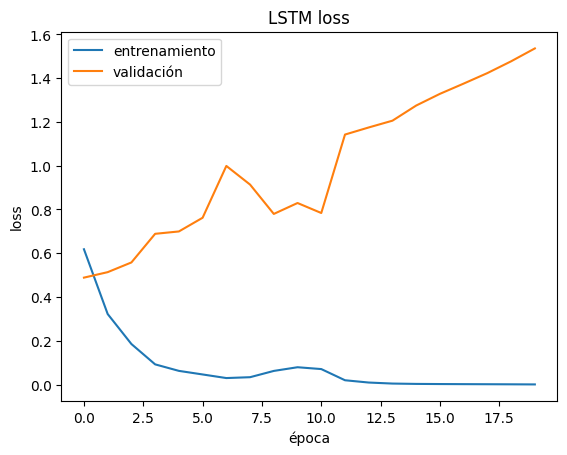

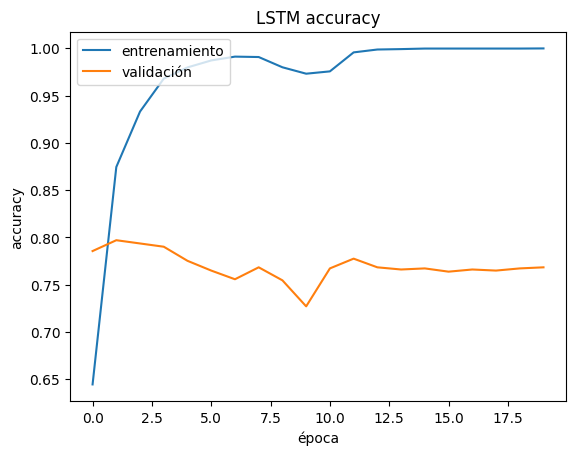

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7775 - loss: 1.5542
Accuracy:  0.7803404927253723


In [19]:
import matplotlib.pyplot as plt

# Visulizamos la evolución del LOSS y el ACCURACY de entrenamiento y validación por épocas de entrenamiento
# TO DO
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM loss')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

plt.figure()
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])
plt.title('LSTM accuracy')
plt.ylabel('accuracy')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()
# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])

**Ejercicio 2b - Tamaño de embeddings y número de unidades LSTM**



Prueba diferentes tamaños de embeddings y número de unidades LSTM.
¿Observas alguna diferencia en las curvas de pérdida y precisión?
¿Qué sucede con un tamaño de embeddings muy pequeño (por ejemplo, 8) o unidades LSTM (por ejemplo, 16)? ¿Y qué ocurre cuando hacemos lo contrario?



Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.5240 - loss: 0.6902 - val_accuracy: 0.6147 - val_loss: 0.6516
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.7140 - loss: 0.5816 - val_accuracy: 0.8016 - val_loss: 0.4798
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8667 - loss: 0.3554 - val_accuracy: 0.8028 - val_loss: 0.4678
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9260 - loss: 0.2169 - val_accuracy: 0.7833 - val_loss: 0.4736
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9412 - loss: 0.1712 - val_accuracy: 0.7649 - val_loss: 0.5387
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9483 - loss: 0.1524 - val_accuracy: 0.7443 - val_loss: 0.6085
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9518 - loss: 0.1535 - val_accuracy: 0.7810 - val_loss: 0.6208
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9671 - loss: 0.1051 - val_accuracy: 0.7764 - v

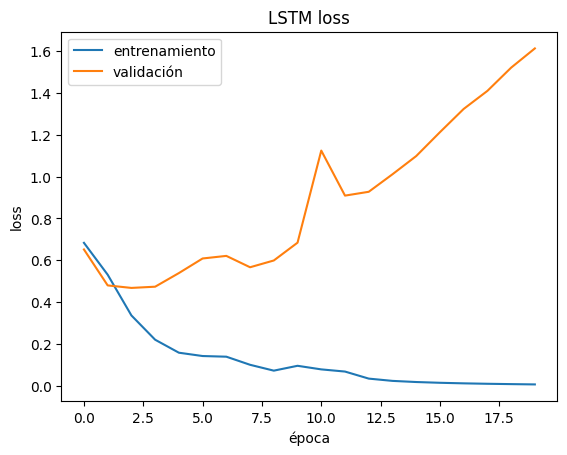

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7727 - loss: 1.7128
Accuracy:  0.7699066400527954


In [20]:
# TO DO
embedding_size = 8
lstm_hidden_size = 128

model = Sequential()

# Añadimos una capa de embeddings
# Usamos mask_zero=True para ignorar los token '0' en el padding
# Tras la capa de embeddings, las activaciones tienen la forma (batch_size, max_seq, embedding_size)
model.add(Embedding(max_words, embedding_size, mask_zero=True))

# Añadimos una capa LSTM
model.add(LSTM(lstm_hidden_size))

# Añadimos una capa de salida
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()
history_lstm = model.fit(x_training, y_training, epochs=20, batch_size=128, validation_data=(x_validation, y_validation), verbose=1)

# Visulizamos la evolución del LOSS y el ACCURACY de entrenamiento y validación por épocas de entrenamiento
# TO DO
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM loss')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.5686 - loss: 0.6813 - val_accuracy: 0.7672 - val_loss: 0.5518
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8364 - loss: 0.4506 - val_accuracy: 0.8085 - val_loss: 0.4448
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9244 - loss: 0.2345 - val_accuracy: 0.8005 - val_loss: 0.4922
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9590 - loss: 0.1392 - val_accuracy: 0.7913 - val_loss: 0.5503
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9797 - loss: 0.0864 - val_accuracy: 0.7878 - val_loss: 0.5969
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9869 - loss: 0.0585 - val_accuracy: 0.7970 - val_loss: 0.6272
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9865 - loss: 0.0501 - val_accuracy: 0.7844 - val_loss: 0.6673
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9860 - loss: 0.0527 - val_accuracy: 0.7729 - v

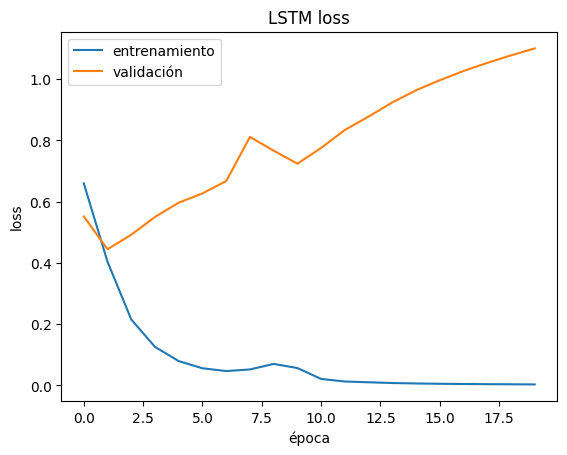

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7881 - loss: 1.1813
Accuracy:  0.7814387679100037


In [21]:
embedding_size = 128
lstm_hidden_size = 16

model = Sequential()

# Añadimos una capa de embeddings
# Usamos mask_zero=True para ignorar los token '0' en el padding
# Tras la capa de embeddings, las activaciones tienen la forma (batch_size, max_seq, embedding_size)
model.add(Embedding(max_words, embedding_size, mask_zero=True))

# Añadimos una capa LSTM
model.add(LSTM(lstm_hidden_size))

# Añadimos una capa de salida
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()
history_lstm = model.fit(x_training, y_training, epochs=20, batch_size=128, validation_data=(x_validation, y_validation), verbose=1)

# Visulizamos la evolución del LOSS y el ACCURACY de entrenamiento y validación por épocas de entrenamiento
# TO DO
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM loss')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_80 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 14s 214ms/step - accuracy: 0.6040 - loss: 0.6514 - val_accuracy: 0.7672 - val_loss: 0.4961
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 210ms/step - accuracy: 0.8668 - loss: 0.3335 - val_accuracy: 0.7810 - val_loss: 0.4712
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - accuracy: 0.9325 - loss: 0.1762 - val_accuracy: 0.7638 - val_loss: 0.5599
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 11s 209ms/step - accuracy: 0.9669 - loss: 0.1003 - val_accuracy: 0.7787 - val_loss: 0.7234
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 210ms/step - accuracy: 0.9768 - loss: 0.0685 - val_accuracy: 0.7787 - val_loss: 0.8324
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 212ms/step - accuracy: 0.9763 - loss: 0.0723 - val_accuracy: 0.7557 - val_loss: 0.7302
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 212ms/step - accuracy: 0.9662 - loss: 0.0921 - val_accuracy: 0.7534 - val_loss: 0.6844
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 12s 212ms/step - accuracy: 0.9858 - loss: 0.0512 - val_accu

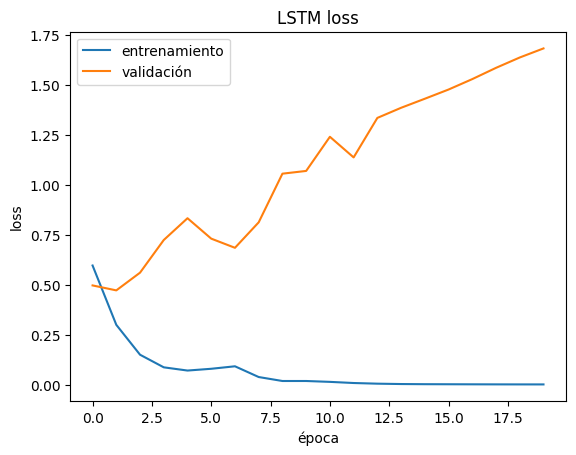

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7912 - loss: 1.7194
Accuracy:  0.7874794006347656


In [22]:
embedding_size = 256
lstm_hidden_size = 256

model = Sequential()

# Añadimos una capa de embeddings
# Usamos mask_zero=True para ignorar los token '0' en el padding
# Tras la capa de embeddings, las activaciones tienen la forma (batch_size, max_seq, embedding_size)
model.add(Embedding(max_words, embedding_size, mask_zero=True))

# Añadimos una capa LSTM
model.add(LSTM(lstm_hidden_size))

# Añadimos una capa de salida
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()
history_lstm = model.fit(x_training, y_training, epochs=20, batch_size=128, validation_data=(x_validation, y_validation), verbose=1)

# Visulizamos la evolución del LOSS y el ACCURACY de entrenamiento y validación por épocas de entrenamiento
# TO DO
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM loss')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.5235 - loss: 0.6916 - val_accuracy: 0.5424 - val_loss: 0.6763
Epoch 2/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6560 - loss: 0.6359 - val_accuracy: 0.7661 - val_loss: 0.5503
Epoch 3/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8374 - loss: 0.4533 - val_accuracy: 0.8028 - val_loss: 0.4656
Epoch 4/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8939 - loss: 0.3101 - val_accuracy: 0.7982 - val_loss: 0.4741
Epoch 5/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9262 - loss: 0.2311 - val_accuracy: 0.7970 - val_loss: 0.4993
Epoch 6/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9445 - loss: 0.1757 - val_accuracy: 0.8005 - val_loss: 0.5513
Epoch 7/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9564 - loss: 0.1452 - val_accuracy: 0.7959 - val_loss: 0.5735
Epoch 8/20
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9673 - loss: 0.1201 - val_accuracy: 0.7936 - v

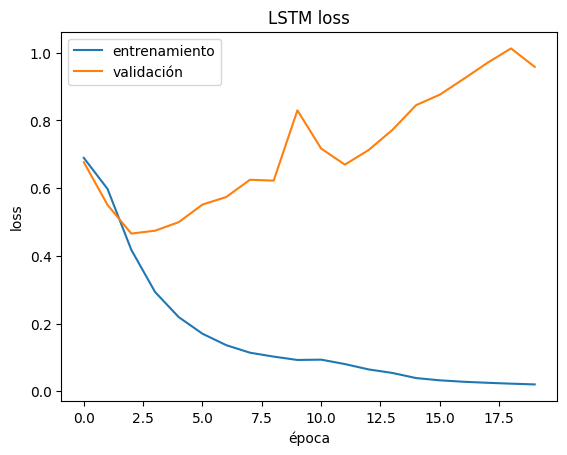

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7651 - loss: 1.0431
Accuracy:  0.7655134797096252


In [23]:
embedding_size = 8
lstm_hidden_size = 16

model = Sequential()

# Añadimos una capa de embeddings
# Usamos mask_zero=True para ignorar los token '0' en el padding
# Tras la capa de embeddings, las activaciones tienen la forma (batch_size, max_seq, embedding_size)
model.add(Embedding(max_words, embedding_size, mask_zero=True))

# Añadimos una capa LSTM
model.add(LSTM(lstm_hidden_size))

# Añadimos una capa de salida
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()
history_lstm = model.fit(x_training, y_training, epochs=20, batch_size=128, validation_data=(x_validation, y_validation), verbose=1)

# Visulizamos la evolución del LOSS y el ACCURACY de entrenamiento y validación por épocas de entrenamiento
# TO DO
plt.figure()
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])
plt.title('LSTM loss')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])

# ***Ejercicio 3 - LSTMs avanzadas***

**Ejercicio 3a - Stacked LSTMs**

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 10s 143ms/step - accuracy: 0.5171 - loss: 0.6928 - val_accuracy: 0.5126 - val_loss: 0.6881
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.5850 - loss: 0.6704 - val_accuracy: 0.7179 - val_loss: 0.5741
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.7575 - loss: 0.5216 - val_accuracy: 0.7649 - val_loss: 0.5139
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.8513 - loss: 0.3758 - val_accuracy: 0.7844 - val_loss: 0.5292
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step - accuracy: 0.9012 - loss: 0.2666 - val_accuracy: 0.7867 - val_loss: 0.5694
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 138ms/step - accuracy: 0.9326 - loss: 0.1983 - val_accuracy: 0.7787 - val_loss: 0.6129
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.9536 - loss: 0.1446 - val_accuracy: 0.7741 - val_loss: 0.6806
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.9670 - loss: 0.1042 - val_accuracy: 0

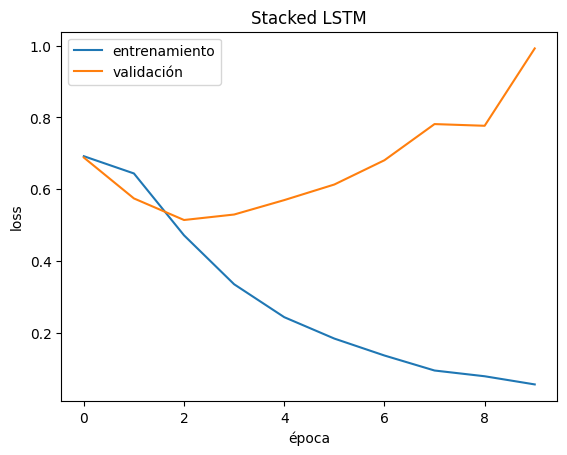

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7812 - loss: 1.0029
Accuracy:  0.7786930203437805


In [24]:
# Creamos un stack con capa de entrada de embeddings, dos capas intermedias (ocultas) de LSTMs, y una capa de salida con función de activación sigmoidal
model = Sequential()
embedding_size = 128
lstm_hidden_size = 128
# TO DO
model.add(Embedding(max_words, embedding_size, mask_zero=True))
model.add(LSTM(lstm_hidden_size, return_sequences=True))
model.add(LSTM(lstm_hidden_size))
model.add(Dense(1, activation='sigmoid'))

# Usamos el optimizador RMSProp (Root Mean Square Propagation) appropiado para RNNs
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])
model.summary()

# Entrenamos el modelo
history_lstm_stacked = model.fit(x_training, y_training, epochs=10, batch_size=128, validation_data=(x_validation, y_validation), verbose=1)

plt.plot(history_lstm_stacked.history['loss'])
plt.plot(history_lstm_stacked.history['val_loss'])
plt.title('Stacked LSTM')
plt.ylabel('loss')
plt.xlabel('época')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])

**Ejercicio 3b - Bidirectional LSTMs**

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
55/55 - 9s - 157ms/step - accuracy: 0.6270 - loss: 0.6411 - val_accuracy: 0.7385 - val_loss: 0.5527
Epoch 2/10
55/55 - 6s - 108ms/step - accuracy: 0.8514 - loss: 0.3736 - val_accuracy: 0.8039 - val_loss: 0.4781
Epoch 3/10
55/55 - 6s - 108ms/step - accuracy: 0.9279 - loss: 0.1953 - val_accuracy: 0.7856 - val_loss: 0.5448
Epoch 4/10
55/55 - 6s - 108ms/step - accuracy: 0.9632 - loss: 0.1185 - val_accuracy: 0.7615 - val_loss: 0.7340
Epoch 5/10
55/55 - 6s - 108ms/step - accuracy: 0.9594 - loss: 0.1173 - val_accuracy: 0.7580 - val_loss: 0.8332
Epoch 6/10
55/55 - 6s - 109ms/step - accuracy: 0.9702 - loss: 0.0955 - val_accuracy: 0.7603 - val_loss: 1.0210
Epoch 7/10
55/55 - 6s - 108ms/step - accuracy: 0.9678 - loss: 0.1012 - val_accuracy: 0.7844 - val_loss: 0.7752
Epoch 8/10
55/55 - 6s - 109ms/step - accuracy: 0.9812 - loss: 0.0553 - val_accuracy: 0.7706 - val_loss: 0.9440
Epoch 9/10
55/55 - 6s - 108ms/step - accuracy: 0.9847 - loss: 0.0466 - val_accuracy: 0.7569 - val_loss: 1.1076
E

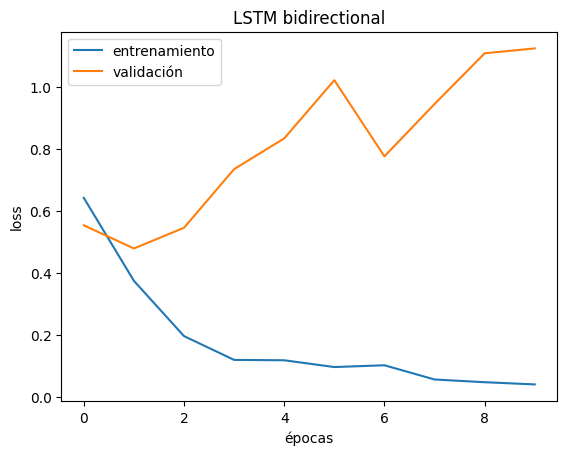

57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7748 - loss: 1.1355
Accuracy:  0.7814387679100037


In [25]:
from tensorflow.keras.layers import Bidirectional

max_words = 10000
embedding_size = 50

# Creamos una red con una capa de entrada de embeddings, una capa intermedia (oculta) con una biLSTM de tamaño 128, y una capa de salida con función de activación sigmoidal
model = Sequential()
# TO DO
model.add(Embedding(max_words, embedding_size, mask_zero=True))
model.add(Bidirectional(LSTM(128)))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Entrenamos el modelo
history_bidirectional = model.fit(x_training, y_training, epochs=10, batch_size=128, validation_data=(x_validation, y_validation), verbose=2)

plt.plot(history_bidirectional.history['loss'])
plt.plot(history_bidirectional.history['val_loss'])
plt.title('LSTM bidirectional')
plt.ylabel('loss')
plt.xlabel('épocas')
plt.legend(['entrenamiento', 'validación'], loc='upper left')
plt.show()

# Evaluamos el modelo en test
score = model.evaluate(x_test, y_test, verbose=1)
print("Accuracy: ", score[1])